# ⚡ 能量的博弈——彭曼-蒙蒂斯方程
# ⚡ The Energy Balance Game — Penman-Monteith Equation

---

## 📚 学习目标 / Learning Objectives

在上一讲中，我们学习了只用温度估算ET的Hargreaves公式。但在现实中，ET还受到很多其他因素的影响：

In the last lecture, we learned the Hargreaves formula that uses only temperature. But in reality, ET is affected by many other factors:

1. **能量供应**：太阳辐射提供多少能量？/ **Energy supply**: How much energy does solar radiation provide?
2. **大气需求**：空气有多干燥？风有多大？/ **Atmospheric demand**: How dry is the air? How strong is the wind?
3. **表面阻力**：植物气孔张开程度如何？/ **Surface resistance**: How open are the plant stomata?

本讲将介绍世界上最权威的ET公式：**彭曼-蒙蒂斯（Penman-Monteith）方程**，它是联合国粮农组织（FAO）推荐的标准方法。

This lecture introduces the world's most authoritative ET formula: the **Penman-Monteith equation**, the standard method recommended by the UN Food and Agriculture Organization (FAO).

### 你将学会 / You will learn:

1. 能量平衡的基本原理 / Basic principles of energy balance
2. "阻力网络"类比 / "Resistance network" analogy
3. 使用PM方程计算ET / Calculate ET using the PM equation
4. 控制变量法实验：风速、湿度、辐射的影响 / Control variable experiments: effects of wind, humidity, radiation

---

## 🔌 核心概念：电路类比 / Core Concept: Electrical Circuit Analogy

### 从电路到水汽传输 / From Electrical Circuits to Water Vapor Transport

想象一个简单的电路：

Imagine a simple electrical circuit:

```
[电池/Battery] ⟶ [电阻1/Resistor 1] ⟶ [电阻2/Resistor 2] ⟶ [接地/Ground]
    电压V              R1                   R2
    Voltage            (Surface)            (Aerodynamic)
```

**欧姆定律 / Ohm's Law:**

$$
I = \frac{V}{R_1 + R_2}
$$

**水汽传输类比 / Water Vapor Transport Analogy:**

```
[叶片内部/Inside Leaf] ⟶ [气孔阻力/Stomatal Resistance] ⟶ [空气阻力/Aerodynamic Resistance] ⟶ [大气/Atmosphere]
     e_s (饱和)                 r_s                              r_a
  (saturated)            (Surface)                        (Aerodynamic)
```

**蒸腾通量 / Transpiration Flux:**

$$
E = \frac{e_s - e_a}{r_s + r_a}
$$

其中 / Where:
- $e_s$: 叶片表面饱和水汽压（"电压"）/ Saturation vapor pressure at leaf surface ("voltage")
- $e_a$: 大气实际水汽压（"地电位"）/ Actual vapor pressure in atmosphere ("ground")
- $r_s$: 气孔阻力（植物控制）/ Stomatal resistance (plant control)
- $r_a$: 空气动力学阻力（风速控制）/ Aerodynamic resistance (wind control)

### 物理意义 / Physical Meaning

1. **"电压"越大（VPD越大）** → 蒸发驱动力越强 / Larger "voltage" (VPD) → Stronger evaporation driving force
2. **阻力越小** → 水汽传输越快 / Smaller resistance → Faster vapor transport
3. **风速越大** → $r_a$ 越小 → 蒸发越快 / Higher wind speed → Smaller $r_a$ → Faster evaporation
4. **气孔关闭** → $r_s$ 变大 → 蒸腾减少 / Stomata close → Larger $r_s$ → Reduced transpiration

---

## 🧮 彭曼-蒙蒂斯方程 / The Penman-Monteith Equation

### 完整公式 / Complete Formula

$$
\text{ET}_0 = \frac{0.408 \Delta (R_n - G) + \gamma \frac{900}{T + 273} u_2 (e_s - e_a)}{\Delta + \gamma (1 + 0.34 u_2)}
$$

看起来很复杂？让我们拆解一下：/ Looks complex? Let's break it down:

### 分子（Numerator）：两种驱动力 / Two Driving Forces

#### 1. 辐射项（能量驱动）/ Radiation Term (Energy-driven)

$$
0.408 \Delta (R_n - G)
$$

- $R_n$: 净辐射（能量输入）/ Net radiation (energy input)
- $G$: 土壤热通量（能量损失）/ Soil heat flux (energy loss)
- $\Delta$: 饱和水汽压曲线斜率（温度敏感性）/ Slope of vapor pressure curve (temperature sensitivity)

**物理意义 / Physical meaning:** 有多少能量可以用来蒸发水？/ How much energy is available to evaporate water?

#### 2. 空气动力学项（通风驱动）/ Aerodynamic Term (Ventilation-driven)

$$
\gamma \frac{900}{T + 273} u_2 (e_s - e_a)
$$

- $u_2$: 2米高度风速 / Wind speed at 2m height
- $(e_s - e_a)$: 水汽压差（VPD）/ Vapor pressure deficit
- $\gamma$: 干湿表常数 / Psychrometric constant

**物理意义 / Physical meaning:** 风有多强？空气有多干？/ How strong is the wind? How dry is the air?

### 分母（Denominator）：能量分配 / Energy Partitioning

$$
\Delta + \gamma (1 + 0.34 u_2)
$$

**物理意义 / Physical meaning:** 能量如何在显热（加热空气）和潜热（蒸发）之间分配？/ How is energy partitioned between sensible heat (heating air) and latent heat (evaporation)?

---

## 💻 代码实战 / Hands-On Coding

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# 添加项目路径 / Add project path
sys.path.insert(0, os.path.abspath('..'))

from pet_comparison.formulas import penman_monteith
from pet_comparison.utils.constants import (
    saturation_vapor_pressure,
    actual_vapor_pressure,
    slope_saturation_vapor_pressure
)

# 设置绘图风格，确保中文可显示 / Set plot style with Chinese-capable fonts
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded successfully!")
print("✅ 库加载成功！")

✅ Libraries loaded successfully!
✅ 库加载成功！


### 示例：计算标准条件下的ET / Example: Calculate ET under Standard Conditions

In [2]:
# 标准气象条件 / Standard meteorological conditions
T = 25.0          # 温度 / Temperature (°C)
RH = 60.0         # 相对湿度 / Relative humidity (%)
u2 = 2.5          # 风速 / Wind speed (m/s)
Rn = 15.0         # 净辐射 / Net radiation (MJ m^-2 day^-1)
P = 101.3         # 气压 / Atmospheric pressure (kPa)

# 计算ET0 / Calculate ET0
et0 = penman_monteith(
    temperature=T,
    relative_humidity=RH,
    wind_speed=u2,
    net_radiation=Rn,
    pressure=P
)

print("🌤️ 标准气象条件 / Standard Meteorological Conditions")
print("="*60)
print(f"温度 / Temperature:        {T}°C")
print(f"相对湿度 / Humidity:       {RH}%")
print(f"风速 / Wind speed:         {u2} m/s")
print(f"净辐射 / Net radiation:    {Rn} MJ m^-2 day^-1")
print(f"气压 / Pressure:           {P} kPa")
print(f"\n💧 参考蒸散发 / Reference ET0: {et0:.2f} mm/day")

# 计算驱动力组分 / Calculate driving force components
es = saturation_vapor_pressure(T)
ea = actual_vapor_pressure(T, relative_humidity=RH)
vpd = es - ea
delta = slope_saturation_vapor_pressure(T)

print(f"\n🔍 诊断信息 / Diagnostic Information:")
print(f"  饱和水汽压 e_s / Saturation vapor pressure:     {es:.3f} kPa")
print(f"  实际水汽压 e_a / Actual vapor pressure:         {ea:.3f} kPa")
print(f"  水汽压差 VPD / Vapor pressure deficit:          {vpd:.3f} kPa")
print(f"  斜率 Δ / Slope of e_s curve:                    {delta:.4f} kPa/°C")

🌤️ 标准气象条件 / Standard Meteorological Conditions
温度 / Temperature:        25.0°C
相对湿度 / Humidity:       60.0%
风速 / Wind speed:         2.5 m/s
净辐射 / Net radiation:    15.0 MJ m^-2 day^-1
气压 / Pressure:           101.3 kPa

💧 参考蒸散发 / Reference ET0: 5.74 mm/day

🔍 诊断信息 / Diagnostic Information:
  饱和水汽压 e_s / Saturation vapor pressure:     3.168 kPa
  实际水汽压 e_a / Actual vapor pressure:         1.901 kPa
  水汽压差 VPD / Vapor pressure deficit:          1.267 kPa
  斜率 Δ / Slope of e_s curve:                    0.1887 kPa/°C


---

## 🧪 实验1：风速的影响 / Experiment 1: Effect of Wind Speed

### 问题：为什么风会加速蒸发？ / Question: Why does wind accelerate evaporation?

**假设 / Hypothesis:**
- 风速 ↑ → 空气动力学阻力 $r_a$ ↓ → 水汽传输更快 → ET ↑
- Wind speed ↑ → Aerodynamic resistance $r_a$ ↓ → Faster vapor transport → ET ↑

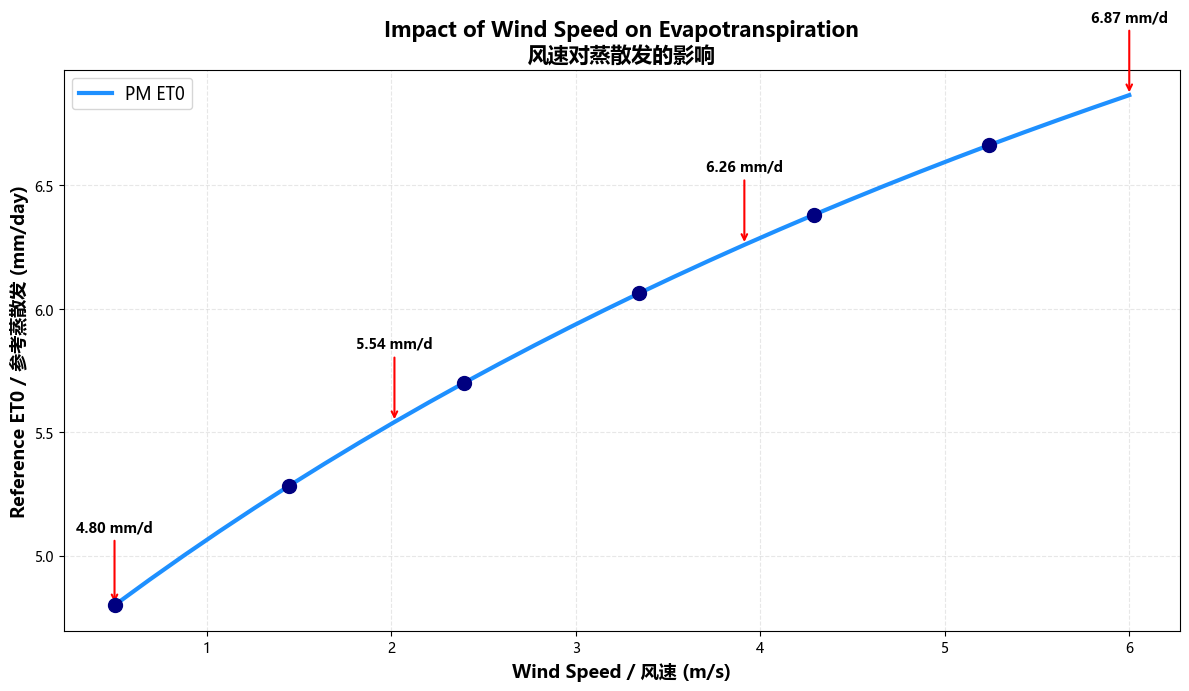


📊 实验结果 / Experimental Results:
静风 (0.5 m/s):  ET0 = 4.80 mm/day
微风 (2.0 m/s):  ET0 = 5.54 mm/day
强风 (6.0 m/s):  ET0 = 6.87 mm/day

💡 增幅 / Increase: 43.1%

🌬️ 结论 / Conclusion: 风速增加 ↑ → ET显著增加 ↑
🌬️ Conclusion: Wind speed increase ↑ → Significant ET increase ↑


In [3]:
# 固定其他变量 / Fix other variables
T_fixed = 25.0
RH_fixed = 60.0
Rn_fixed = 15.0

# 风速范围 / Wind speed range
wind_speeds = np.linspace(0.5, 6.0, 30)  # 0.5 to 6 m/s

# 计算不同风速下的ET / Calculate ET for different wind speeds
et0_wind = []
for u in wind_speeds:
    et = penman_monteith(
        temperature=T_fixed,
        relative_humidity=RH_fixed,
        wind_speed=u,
        net_radiation=Rn_fixed
    )
    et0_wind.append(et)

et0_wind = np.array(et0_wind)

# 绘图 / Plot
plt.figure(figsize=(12, 7))
plt.plot(wind_speeds, et0_wind, linewidth=3, color='dodgerblue', label='PM ET0')
plt.scatter(wind_speeds[::5], et0_wind[::5], s=100, color='navy', zorder=5)

# 标注关键点 / Annotate key points
for u_mark in [0.5, 2.0, 4.0, 6.0]:
    idx = np.argmin(np.abs(wind_speeds - u_mark))
    plt.annotate(f'{et0_wind[idx]:.2f} mm/d', 
                xy=(wind_speeds[idx], et0_wind[idx]), 
                xytext=(wind_speeds[idx], et0_wind[idx] + 0.3),
                ha='center', fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('Wind Speed / 风速 (m/s)', fontsize=13, fontweight='bold')
plt.ylabel('Reference ET0 / 参考蒸散发 (mm/day)', fontsize=13, fontweight='bold')
plt.title('Impact of Wind Speed on Evapotranspiration\n风速对蒸散发的影响', 
          fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 实验结果 / Experimental Results:")
print("="*60)
print(f"静风 (0.5 m/s):  ET0 = {et0_wind[0]:.2f} mm/day")
print(f"微风 (2.0 m/s):  ET0 = {et0_wind[np.argmin(np.abs(wind_speeds - 2.0))]:.2f} mm/day")
print(f"强风 (6.0 m/s):  ET0 = {et0_wind[-1]:.2f} mm/day")
print(f"\n💡 增幅 / Increase: {(et0_wind[-1] / et0_wind[0] - 1) * 100:.1f}%")
print(f"\n🌬️ 结论 / Conclusion: 风速增加 ↑ → ET显著增加 ↑")
print(f"🌬️ Conclusion: Wind speed increase ↑ → Significant ET increase ↑")

---

## 🧪 实验2：湿度的影响 / Experiment 2: Effect of Humidity

### 问题：为什么干燥的空气蒸发更快？ / Question: Why does dry air evaporate faster?

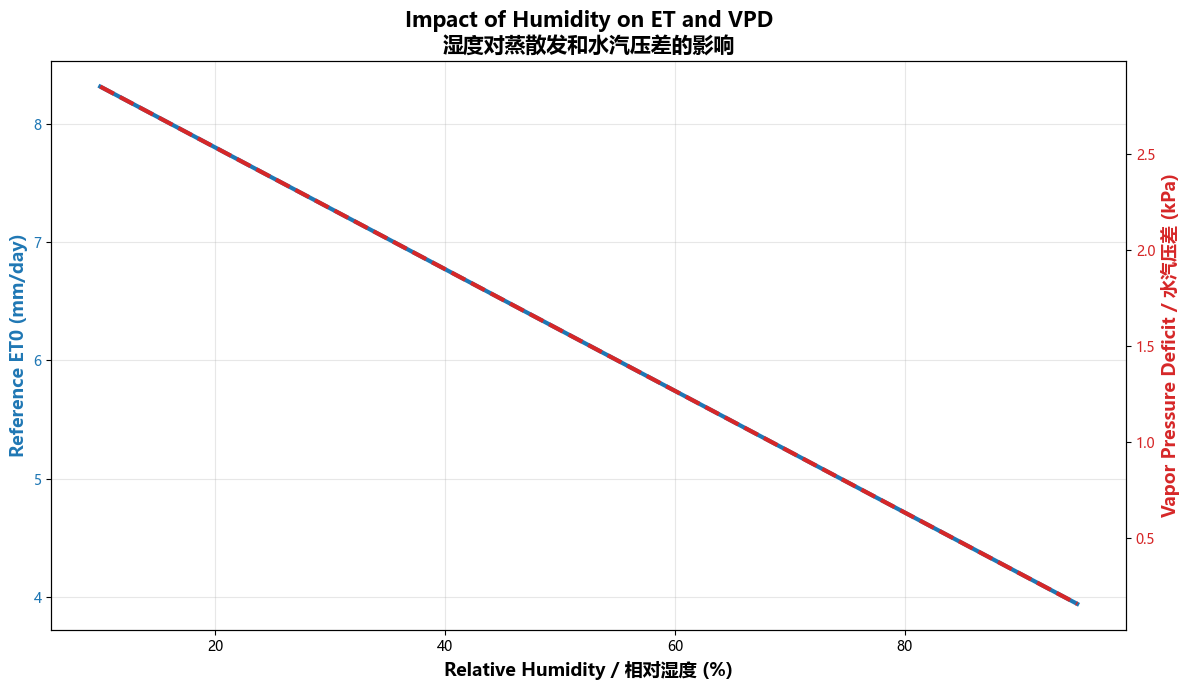


📊 实验结果 / Experimental Results:
干燥空气 (RH=20%):  ET0 = 7.86 mm/day, VPD = 2.57 kPa
中等湿度 (RH=60%):  ET0 = 5.75 mm/day, VPD = 1.27 kPa
潮湿空气 (RH=90%):  ET0 = 4.24 mm/day, VPD = 0.34 kPa

💡 关键发现 / Key Finding: ET与VPD呈正相关！
💡 Key Finding: ET is positively correlated with VPD!

🌵 干燥空气（低RH） → 高VPD → 强蒸发驱动力 → 高ET
🌵 Dry air (low RH) → High VPD → Strong evaporation driving force → High ET


In [4]:
# 固定其他变量 / Fix other variables
T_fixed = 25.0
u2_fixed = 2.5
Rn_fixed = 15.0

# 相对湿度范围 / Relative humidity range
humidities = np.linspace(10, 95, 30)  # 10% to 95%

# 计算不同湿度下的ET和VPD / Calculate ET and VPD for different humidities
et0_rh = []
vpd_rh = []

for rh in humidities:
    et = penman_monteith(
        temperature=T_fixed,
        relative_humidity=rh,
        wind_speed=u2_fixed,
        net_radiation=Rn_fixed
    )
    et0_rh.append(et)
    
    # 计算VPD / Calculate VPD
    es = saturation_vapor_pressure(T_fixed)
    ea = actual_vapor_pressure(T_fixed, relative_humidity=rh)
    vpd = es - ea
    vpd_rh.append(vpd)

et0_rh = np.array(et0_rh)
vpd_rh = np.array(vpd_rh)

# 双轴图 / Dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# 左轴：ET / Left axis: ET
color = 'tab:blue'
ax1.set_xlabel('Relative Humidity / 相对湿度 (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Reference ET0 (mm/day)', fontsize=13, fontweight='bold', color=color)
ax1.plot(humidities, et0_rh, linewidth=3, color=color, label='ET0')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# 右轴：VPD / Right axis: VPD
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Vapor Pressure Deficit / 水汽压差 (kPa)', fontsize=13, fontweight='bold', color=color)
ax2.plot(humidities, vpd_rh, linewidth=3, linestyle='--', color=color, label='VPD')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Humidity on ET and VPD\n湿度对蒸散发和水汽压差的影响', 
          fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

print("\n📊 实验结果 / Experimental Results:")
print("="*60)
print(f"干燥空气 (RH=20%):  ET0 = {et0_rh[np.argmin(np.abs(humidities - 20))]:.2f} mm/day, VPD = {vpd_rh[np.argmin(np.abs(humidities - 20))]:.2f} kPa")
print(f"中等湿度 (RH=60%):  ET0 = {et0_rh[np.argmin(np.abs(humidities - 60))]:.2f} mm/day, VPD = {vpd_rh[np.argmin(np.abs(humidities - 60))]:.2f} kPa")
print(f"潮湿空气 (RH=90%):  ET0 = {et0_rh[np.argmin(np.abs(humidities - 90))]:.2f} mm/day, VPD = {vpd_rh[np.argmin(np.abs(humidities - 90))]:.2f} kPa")
print(f"\n💡 关键发现 / Key Finding: ET与VPD呈正相关！")
print(f"💡 Key Finding: ET is positively correlated with VPD!")
print(f"\n🌵 干燥空气（低RH） → 高VPD → 强蒸发驱动力 → 高ET")
print(f"🌵 Dry air (low RH) → High VPD → Strong evaporation driving force → High ET")

---

## 🧪 实验3：辐射的影响 / Experiment 3: Effect of Radiation

### 问题：能量供应如何限制蒸发？ / Question: How does energy supply limit evaporation?

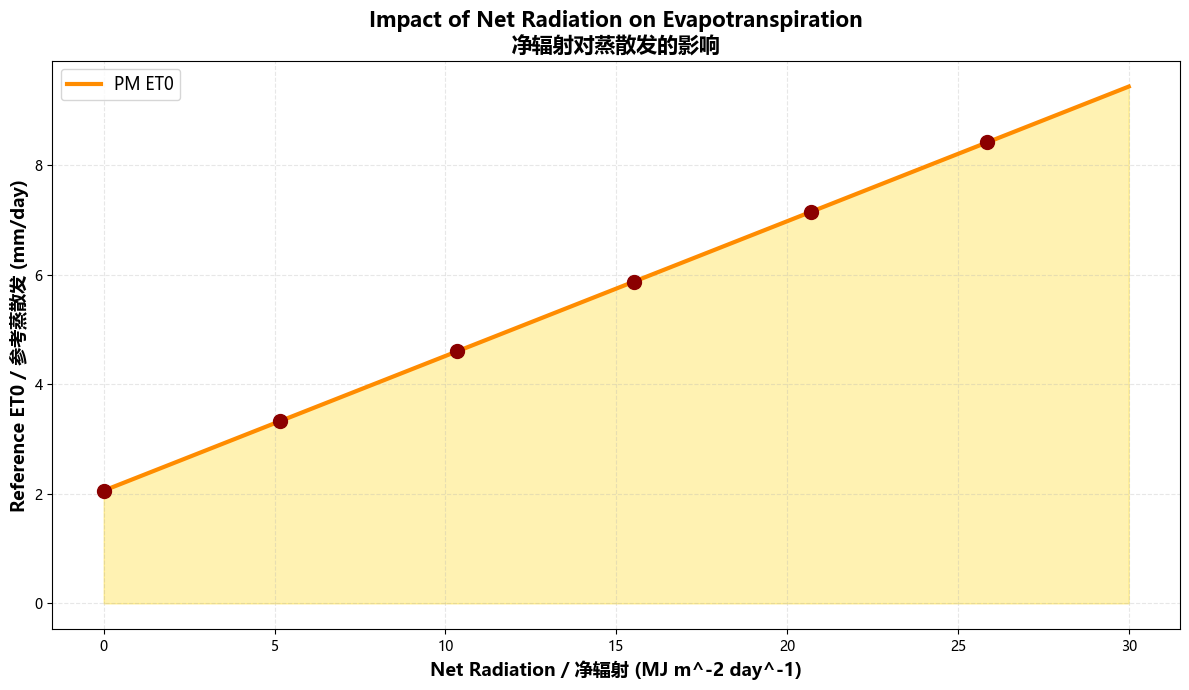


📊 实验结果 / Experimental Results:
阴天 (Rn=5):    ET0 = 3.33 mm/day
晴天 (Rn=15):   ET0 = 5.62 mm/day
极晴 (Rn=25):   ET0 = 8.16 mm/day

☀️ 结论 / Conclusion: 辐射提供蒸发所需的能量，是ET的主要驱动力！
☀️ Conclusion: Radiation provides energy for evaporation and is a major ET driver!

💡 注意：即使在Rn=0时，ET仍不为0（空气动力学项贡献）
💡 Note: Even at Rn=0, ET is non-zero (contribution from aerodynamic term)


In [5]:
# 固定其他变量 / Fix other variables
T_fixed = 25.0
RH_fixed = 60.0
u2_fixed = 2.5

# 净辐射范围 / Net radiation range
radiations = np.linspace(0, 30, 30)  # 0 to 30 MJ m^-2 day^-1

# 计算不同辐射下的ET / Calculate ET for different radiation levels
et0_rn = []
for rn in radiations:
    et = penman_monteith(
        temperature=T_fixed,
        relative_humidity=RH_fixed,
        wind_speed=u2_fixed,
        net_radiation=rn
    )
    et0_rn.append(et)

et0_rn = np.array(et0_rn)

# 绘图 / Plot
plt.figure(figsize=(12, 7))
plt.plot(radiations, et0_rn, linewidth=3, color='darkorange', label='PM ET0')
plt.scatter(radiations[::5], et0_rn[::5], s=100, color='darkred', zorder=5)

# 填充区域 / Fill area
plt.fill_between(radiations, 0, et0_rn, alpha=0.3, color='gold')

plt.xlabel('Net Radiation / 净辐射 (MJ m^-2 day^-1)', fontsize=13, fontweight='bold')
plt.ylabel('Reference ET0 / 参考蒸散发 (mm/day)', fontsize=13, fontweight='bold')
plt.title('Impact of Net Radiation on Evapotranspiration\n净辐射对蒸散发的影响', 
          fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 实验结果 / Experimental Results:")
print("="*60)
print(f"阴天 (Rn=5):    ET0 = {et0_rn[np.argmin(np.abs(radiations - 5))]:.2f} mm/day")
print(f"晴天 (Rn=15):   ET0 = {et0_rn[np.argmin(np.abs(radiations - 15))]:.2f} mm/day")
print(f"极晴 (Rn=25):   ET0 = {et0_rn[np.argmin(np.abs(radiations - 25))]:.2f} mm/day")
print(f"\n☀️ 结论 / Conclusion: 辐射提供蒸发所需的能量，是ET的主要驱动力！")
print(f"☀️ Conclusion: Radiation provides energy for evaporation and is a major ET driver!")
print(f"\n💡 注意：即使在Rn=0时，ET仍不为0（空气动力学项贡献）")
print(f"💡 Note: Even at Rn=0, ET is non-zero (contribution from aerodynamic term)")

---

## 🔥 综合实验：热浪场景模拟 / Comprehensive Experiment: Heatwave Scenario

### 场景：极端高温事件 / Scenario: Extreme Heat Event

让我们模拟一次持续10天的热浪，观察ET的变化：

Let's simulate a 10-day heatwave and observe ET changes:

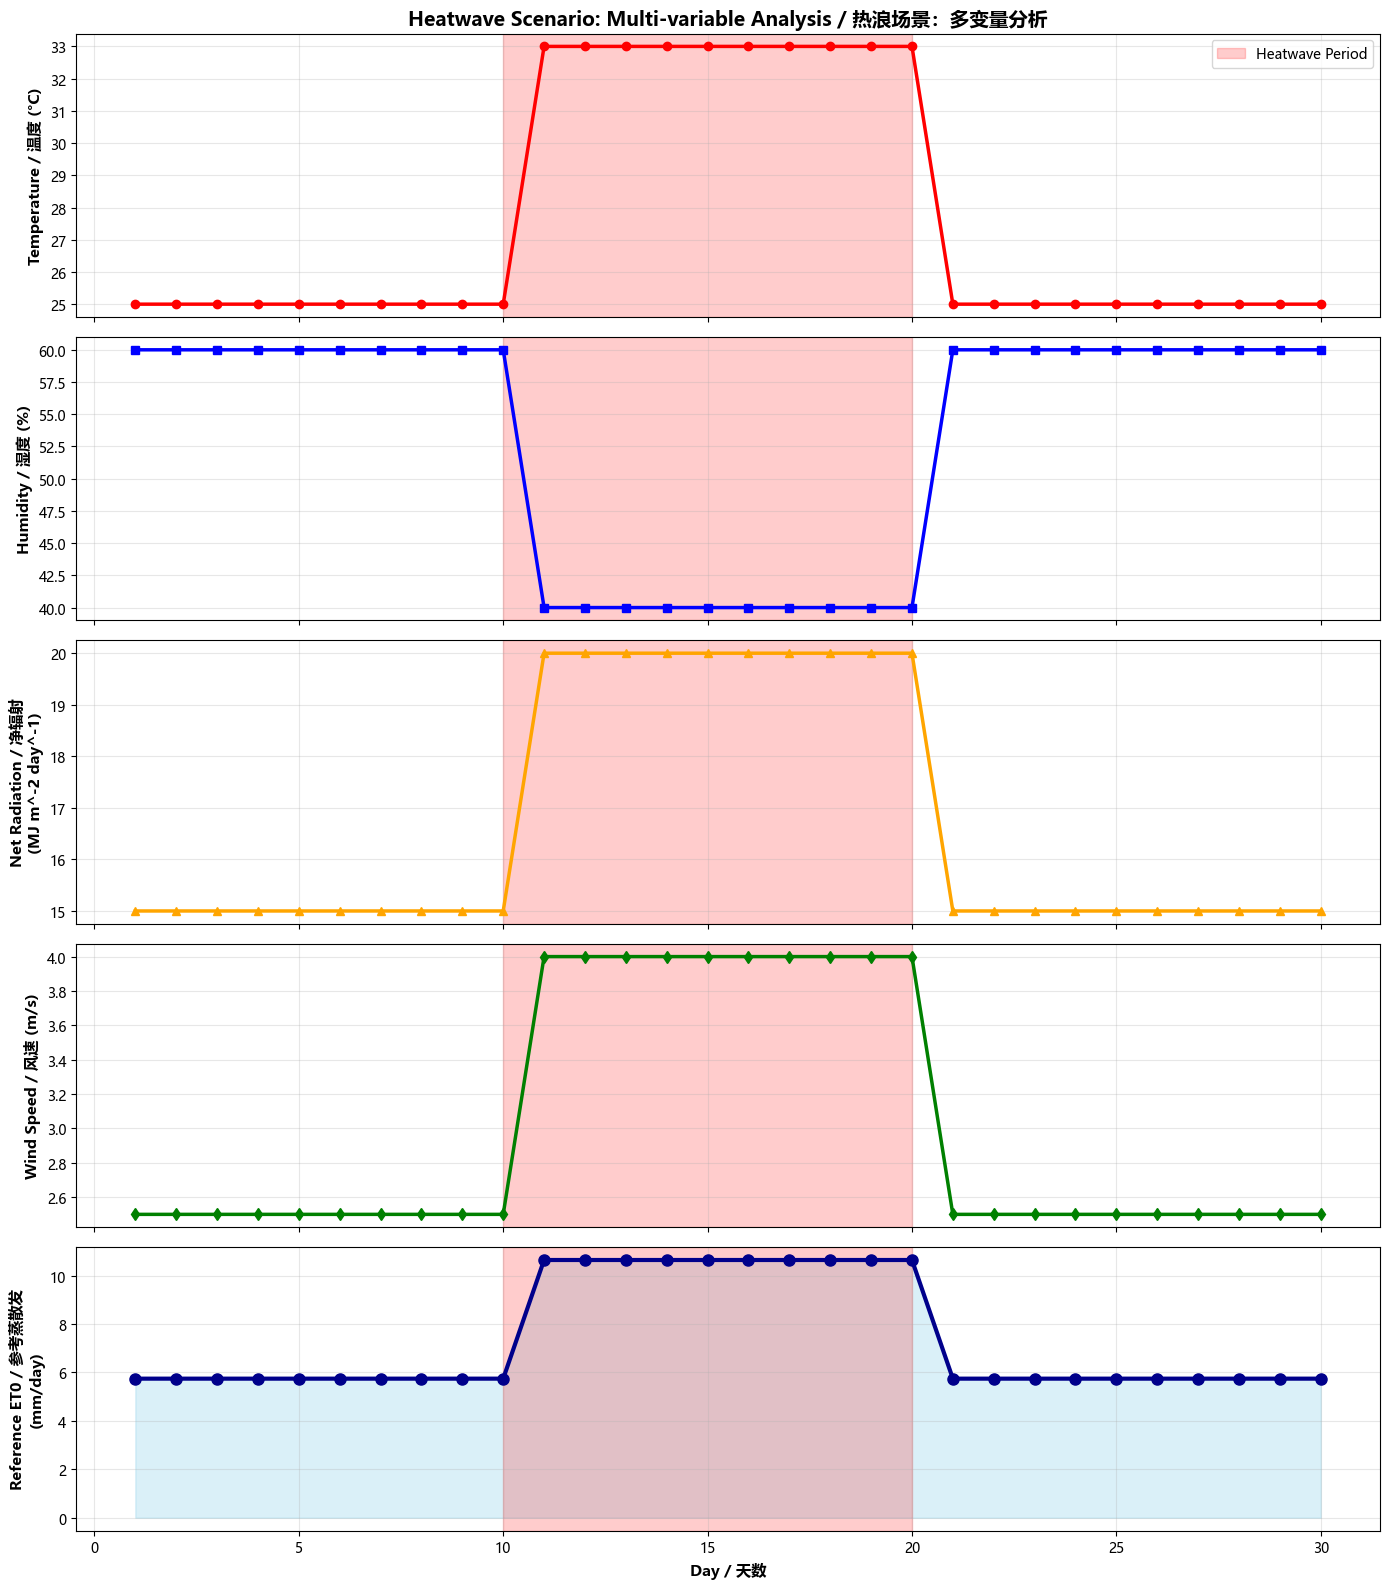


🌡️ 热浪影响分析 / Heatwave Impact Analysis
正常期（第1-10天）/ Normal Period (Days 1-10):
  平均温度 / Mean temperature: 25.0°C
  平均ET / Mean ET: 5.74 mm/day

热浪期（第10-20天）/ Heatwave Period (Days 10-20):
  平均温度 / Mean temperature: 33.0°C
  平均ET / Mean ET: 10.64 mm/day

💥 ET增幅 / ET Increase: 85.3%

💧 10天热浪累积ET / 10-day cumulative ET: 106.4 mm
💧 这相当于 10.6 mm 的额外水分损失！
💧 This is equivalent to an extra 10.6 mm water loss!


In [6]:
# 生成30天数据（中间10天为热浪）/ Generate 30-day data (10-day heatwave in the middle)
days = np.arange(1, 31)

# 温度异常 / Temperature anomaly
T_base = 25.0
T_anomaly = np.zeros(30)
T_anomaly[10:20] = 8.0  # 热浪期间升温8度 / +8°C during heatwave
T_daily = T_base + T_anomaly

# 湿度变化（热浪期间湿度降低）/ Humidity change (decreases during heatwave)
RH_base = 60.0
RH_anomaly = np.zeros(30)
RH_anomaly[10:20] = -20.0  # 热浪期间湿度降低20% / -20% during heatwave
RH_daily = RH_base + RH_anomaly

# 辐射增加 / Radiation increase
Rn_base = 15.0
Rn_anomaly = np.zeros(30)
Rn_anomaly[10:20] = 5.0  # 热浪期间辐射增加 / +5 MJ during heatwave
Rn_daily = Rn_base + Rn_anomaly

# 风速增加 / Wind speed increase
u2_base = 2.5
u2_anomaly = np.zeros(30)
u2_anomaly[10:20] = 1.5  # 热浪期间风速增加 / +1.5 m/s during heatwave
u2_daily = u2_base + u2_anomaly

# 计算每日ET / Calculate daily ET
et0_daily = penman_monteith(
    temperature=T_daily,
    relative_humidity=RH_daily,
    wind_speed=u2_daily,
    net_radiation=Rn_daily
)

# 创建图表 / Create plot
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# 1. 温度 / Temperature
axes[0].plot(days, T_daily, linewidth=2.5, color='red', marker='o')
axes[0].axvspan(10, 20, alpha=0.2, color='red', label='Heatwave Period')
axes[0].set_ylabel('Temperature / 温度 (°C)', fontweight='bold', fontsize=11)
axes[0].set_title('Heatwave Scenario: Multi-variable Analysis / 热浪场景：多变量分析', 
                   fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 湿度 / Humidity
axes[1].plot(days, RH_daily, linewidth=2.5, color='blue', marker='s')
axes[1].axvspan(10, 20, alpha=0.2, color='red')
axes[1].set_ylabel('Humidity / 湿度 (%)', fontweight='bold', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. 辐射 / Radiation
axes[2].plot(days, Rn_daily, linewidth=2.5, color='orange', marker='^')
axes[2].axvspan(10, 20, alpha=0.2, color='red')
axes[2].set_ylabel('Net Radiation / 净辐射\n(MJ m^-2 day^-1)', fontweight='bold', fontsize=11)
axes[2].grid(True, alpha=0.3)

# 4. 风速 / Wind speed
axes[3].plot(days, u2_daily, linewidth=2.5, color='green', marker='d')
axes[3].axvspan(10, 20, alpha=0.2, color='red')
axes[3].set_ylabel('Wind Speed / 风速 (m/s)', fontweight='bold', fontsize=11)
axes[3].grid(True, alpha=0.3)

# 5. ET / ET
axes[4].plot(days, et0_daily, linewidth=3, color='darkblue', marker='o', markersize=8)
axes[4].fill_between(days, 0, et0_daily, alpha=0.3, color='skyblue')
axes[4].axvspan(10, 20, alpha=0.2, color='red')
axes[4].set_ylabel('Reference ET0 / 参考蒸散发\n(mm/day)', fontweight='bold', fontsize=11)
axes[4].set_xlabel('Day / 天数', fontweight='bold', fontsize=11)
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 统计分析 / Statistical analysis
normal_et = et0_daily[:10].mean()
heatwave_et = et0_daily[10:20].mean()
increase = (heatwave_et - normal_et) / normal_et * 100

print("\n🌡️ 热浪影响分析 / Heatwave Impact Analysis")
print("="*60)
print(f"正常期（第1-10天）/ Normal Period (Days 1-10):")
print(f"  平均温度 / Mean temperature: {T_daily[:10].mean():.1f}°C")
print(f"  平均ET / Mean ET: {normal_et:.2f} mm/day")
print(f"\n热浪期（第10-20天）/ Heatwave Period (Days 10-20):")
print(f"  平均温度 / Mean temperature: {T_daily[10:20].mean():.1f}°C")
print(f"  平均ET / Mean ET: {heatwave_et:.2f} mm/day")
print(f"\n💥 ET增幅 / ET Increase: {increase:.1f}%")
print(f"\n💧 10天热浪累积ET / 10-day cumulative ET: {et0_daily[10:20].sum():.1f} mm")
print(f"💧 这相当于 {et0_daily[10:20].sum()/10:.1f} mm 的额外水分损失！")
print(f"💧 This is equivalent to an extra {et0_daily[10:20].sum()/10:.1f} mm water loss!")

---

## 📚 总结与思考 / Summary and Reflection

### 关键收获 / Key Takeaways

1. **多因素驱动 / Multi-factor Driving:**
   - ET不仅取决于温度，还受辐射、湿度、风速的综合影响
   - ET is determined not only by temperature but also by radiation, humidity, and wind speed

2. **阻力网络类比 / Resistance Network Analogy:**
   - 水汽传输类似于电流：驱动力（VPD）/ 阻力（$r_s$ + $r_a$）
   - Vapor transport is like electric current: driving force (VPD) / resistance ($r_s$ + $r_a$)

3. **两种驱动机制 / Two Driving Mechanisms:**
   - **辐射项**：能量限制（有多少能量可用？）
   - **空气动力学项**：大气需求（空气有多干?风有多大？）
   - **Radiation term**: Energy limitation (How much energy is available?)
   - **Aerodynamic term**: Atmospheric demand (How dry? How windy?)

4. **实际应用 / Practical Application:**
   - 热浪期间，多因素协同作用导致ET激增
   - During heatwaves, multiple factors synergize to cause ET surge

### 🤔 思考题 / Discussion Questions

1. **局限性 / Limitations:**
   - PM方程假设表面阻力 $r_s$ 是常数，但实际上植物会根据环境条件调节气孔。如何改进？
   - PM equation assumes constant $r_s$, but plants actually regulate stomata based on conditions. How to improve?

2. **气候变化 / Climate Change:**
   - 在CO2浓度升高的情况下，植物气孔会关闭。这会如何影响ET？
   - With rising CO2, plant stomata close. How would this affect ET?

3. **下一步 / Next Steps:**
   - 如果我们考虑植物的生理响应（气孔调节），能否得到更准确的估算？
   - Can we get more accurate estimates by considering plant physiological responses (stomatal regulation)?

---

## 🚀 下一讲预告 / Preview of Next Lecture

### Notebook 3: 气候变化的悖论——植物也会"憋气"吗？
### Notebook 3: The Climate Change Paradox — Do Plants "Hold Their Breath"?

在下一讲中，我们将探索前沿科学问题：

In the next lecture, we'll explore cutting-edge scientific questions:

1. **蒸发悖论 / Evaporation Paradox:**
   - 全球变暖→温度升高，为什么有些地区的蒸发反而减少？
   - Global warming → Higher temperature, why does evaporation decrease in some regions?

2. **CO2的双重效应 / Dual Effects of CO2:**
   - 温室效应：升温→加速蒸发
   - 气孔效应：高CO2→气孔关闭→抑制蒸发
   - Greenhouse effect: Warming → Accelerated evaporation
   - Stomatal effect: High CO2 → Stomata close → Suppressed evaporation

3. **未来预测 / Future Projections:**
   - 2100年的ET会比现在高还是低？
   - Will ET in 2100 be higher or lower than now?

---

## 📖 参考文献 / References

1. Allen, R. G., et al. (1998). *Crop evapotranspiration - Guidelines for computing crop water requirements*. FAO Irrigation and Drainage Paper 56.

2. Monteith, J. L. (1965). Evaporation and environment. *Symposia of the Society for Experimental Biology*, 19, 205-234.

3. Penman, H. L. (1948). Natural evaporation from open water, bare soil and grass. *Proceedings of the Royal Society of London A*, 193(1032), 120-145.

---

**🎓 结束语 / Closing Remarks**

恭喜你掌握了经典的彭曼-蒙蒂斯方程！你现在可以像专业的气象学家一样计算蒸散发了。但科学永不停步——下一讲我们将探索更前沿的气候变化研究！

Congratulations on mastering the classic Penman-Monteith equation! You can now calculate evapotranspiration like a professional meteorologist. But science never stops—in the next lecture, we'll explore more cutting-edge climate change research!

---